# AVERT — Evaluation & Analysis Notebook
Compares curriculum-trained agent vs scratch baseline across:
- Stage 3 (trained environment)
- Medium-difficulty highway (generalization probe)
- Training efficiency curves
- Transfer learning (roundabout / merge)

Every agent is rendered as a GIF for each environment.

In [1]:
# ── Cell 1: system deps ───────────────────────────────────────────
!apt-get install -y xvfb > /dev/null 2>&1
!pip install highway-env stable-baselines3 gymnasium pyvirtualdisplay imageio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 40.0 MB/s eta 0:00:00


In [2]:
# ── Cell 2: virtual display ───────────────────────────────────────
from pyvirtualdisplay import Display
vdisplay = Display(visible=False, size=(600, 200))
vdisplay.start()
print("Display alive:", vdisplay.is_alive())

Display alive: True


In [3]:
# ── Cell 3: imports + drive ───────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import imageio
import gymnasium as gym
import highway_env
from IPython.display import Image, display
from stable_baselines3 import PPO, A2C
from google.colab import drive

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/AVERT/"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Drive mounted. SAVE_DIR:", SAVE_DIR)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mounted at /content/drive
Drive mounted. SAVE_DIR: /content/drive/MyDrive/AVERT/


In [4]:
# ── Cell 4: custom vehicle + all configs ─────────────────────────
import highway_env.vehicle.behavior as behavior
from highway_env.vehicle.behavior import IDMVehicle

class PursuerVehicle(IDMVehicle):
    """Actively chases the ego vehicle by matching its lane and flooring it."""
    PURSUIT_GAIN = 1.5
    def act(self, action=None):
        ego = self.road.vehicles[0]
        if self.lane_index[2] < ego.lane_index[2]:
            action = "LANE_RIGHT"
        elif self.lane_index[2] > ego.lane_index[2]:
            action = "LANE_LEFT"
        else:
            action = "FASTER"
        super().act(action)

behavior.PursuerVehicle = PursuerVehicle

stage1_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "lanes_count": 4,
    "vehicles_count": 20,
    "duration": 20,
    "other_vehicles_type": "highway_env.vehicle.behavior.IDMVehicle",
    "collision_reward": -2,
    "high_speed_reward": 0.4,
    "right_lane_reward": 0.1,
    "lane_change_reward": 0.0,
    "reward_speed_range": [20, 30],
    "normalize_reward": True,
}

stage2_config = {
    **stage1_config,
    "vehicles_count": 20,
    "other_vehicles_type": "highway_env.vehicle.behavior.AggressiveVehicle",
    "collision_reward": -3,
}

stage3_config = {
    **stage1_config,
    "vehicles_count": 25,
    "other_vehicles_type": "highway_env.vehicle.behavior.PursuerVehicle",
    "collision_reward": -5,
}

# Medium: same pursuer type as Stage 3 but fewer cars + softer collision penalty
# Difficulty sits between Stage 2 and Stage 3
medium_config = {
    **stage1_config,
    "vehicles_count": 20,
    "other_vehicles_type": "highway_env.vehicle.behavior.PursuerVehicle",
    "collision_reward": -3,
}

roundabout_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

merge_config = {
    "observation": {"type": "Kinematics"},
    "action": {"type": "DiscreteMetaAction"},
    "collision_reward": -3,
    "high_speed_reward": 0.4,
    "normalize_reward": True,
}

print("All configs ready.")

All configs ready.


In [5]:
# ── Cell 5: helper functions ──────────────────────────────────────

def render_agent(model, config, env_id="highway-v0", filename="agent.gif", n_episodes=2):
    """Render `n_episodes`, save a GIF to Drive, display inline, and print stats."""
    env = gym.make(env_id, render_mode="rgb_array")
    env.unwrapped.configure(config)
    env.unwrapped.configure({"offscreen_rendering": True})
    frames, rewards, crashed_eps = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        env.step(env.action_space.sample())  # init viewer
        ep_reward, done, truncated, ep_crashed = 0.0, False, False, False
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            frame = env.render()
            if frame is not None:
                frames.append(frame)
            ep_reward += reward
            if info.get("crashed", False):
                ep_crashed = True
        rewards.append(ep_reward)
        crashed_eps.append(ep_crashed)
        crash_tag = "CRASH" if ep_crashed else "survived"
        print(f"  Episode {ep+1}: reward={ep_reward:.2f}  [{crash_tag}]")

    env.close()
    if frames:
        save_path = os.path.join(SAVE_DIR, filename)
        imageio.mimsave(save_path, frames, fps=15)
        display(Image(save_path))
    survival = sum(1 for c in crashed_eps if not c) / n_episodes
    print(f"  Avg reward: {np.mean(rewards):.2f} | Survival: {survival*100:.0f}%")


def eval_agent(model, config, env_id="highway-v0", n_episodes=5, seed=42):
    """Headless evaluation returning reward/crash stats (no frames saved)."""
    env = gym.make(env_id, render_mode=None)
    env.unwrapped.configure(config)
    rewards, crashed_flags = [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_reward, done, truncated, ep_crashed = 0.0, False, False, False
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            ep_reward += reward
            if info.get("crashed", False):
                ep_crashed = True
        rewards.append(ep_reward)
        crashed_flags.append(ep_crashed)
    env.close()
    survival = sum(1 for c in crashed_flags if not c) / n_episodes
    return {
        "rewards": rewards, "crashed": crashed_flags,
        "survival_rate": survival,
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
    }


def smooth(x, w=5):
    if len(x) < w:
        return np.array(x, dtype=float)
    return np.convolve(x, np.ones(w) / w, mode='valid')

print("Helper functions ready.")

Helper functions ready.


In [6]:
# ── Cell 6: load all models ───────────────────────────────────────
from stable_baselines3 import A2C
print("Loading models from Drive...")

SAVE_DIR = "/content/drive/MyDrive/AVERT/"

model_stage1      = A2C.load(SAVE_DIR + "avert_stage1_final")
model_stage2      = A2C.load(SAVE_DIR + "avert_stage2_final")
model_curriculum  = A2C.load(SAVE_DIR + "avert_stage3_final")
model_scratch     = A2C.load(SAVE_DIR + "avert_stage3_scratch_final")

model_roundabout_transfer = A2C.load(SAVE_DIR + "avert_round_transfer_final")
model_roundabout_scratch  = A2C.load(SAVE_DIR + "avert_round_scratch_final")

model_merge_transfer = A2C.load(SAVE_DIR + "avert_merge_transfer_final")
model_merge_scratch  = A2C.load(SAVE_DIR + "avert_merge_scratch_final")

print("All 8 models loaded.")

Loading models from Drive...
All 8 models loaded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:

# Run evals
s3_curr    = eval_agent(model_curriculum, stage3_config,   n_episodes=10)
s3_scratch = eval_agent(model_scratch,    stage3_config,    n_episodes=10)
ra_transfer = eval_agent(model_roundabout_transfer, roundabout_config, "roundabout-v0", n_episodes=10)
ra_scratch  = eval_agent(model_roundabout_scratch,  roundabout_config, "roundabout-v0", n_episodes=10)
mg_transfer = eval_agent(model_merge_transfer, merge_config, "merge-v0", n_episodes=10)
mg_scratch  = eval_agent(model_merge_scratch,  merge_config, "merge-v0", n_episodes=10)

# Print summary table
for label, s in [
    ("Stage3 Curriculum", s3_curr), ("Stage3 Scratch", s3_scratch),
    ("Roundabout Transfer", ra_transfer), ("Roundabout Scratch", ra_scratch),
    ("Merge Transfer", mg_transfer), ("Merge Scratch", mg_scratch),
]:
    print(f"{label:22s}  reward={s['mean_reward']:6.2f}  survival={s['survival_rate']*100:.0f}%")

Stage3 Curriculum       reward= 18.35  survival=100%
Stage3 Scratch          reward= 15.24  survival=50%
Roundabout Transfer     reward=  6.71  survival=60%
Roundabout Scratch      reward=  7.13  survival=70%
Merge Transfer          reward= 15.03  survival=100%
Merge Scratch           reward= 15.03  survival=100%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


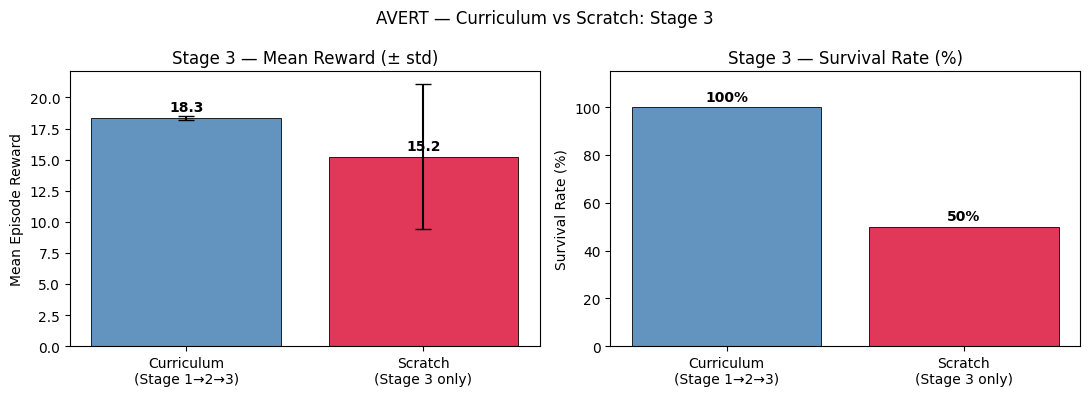

In [9]:
# ── Stage 3 Bar Chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ["Curriculum\n(Stage 1→2→3)", "Scratch\n(Stage 3 only)"]
means  = [s3_curr['mean_reward'],    s3_scratch['mean_reward']]
stds   = [s3_curr['std_reward'],     s3_scratch['std_reward']]
surv   = [s3_curr['survival_rate']*100, s3_scratch['survival_rate']*100]
colors = ["steelblue", "crimson"]

bars = axes[0].bar(labels, means, yerr=stds, color=colors,
                   capsize=6, alpha=0.85, edgecolor='k', linewidth=0.7)
axes[0].set_ylabel("Mean Episode Reward")
axes[0].set_title("Stage 3 — Mean Reward (± std)")
for bar, v in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(labels, surv, color=colors, alpha=0.85,
                    edgecolor='k', linewidth=0.7)
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_ylim(0, 115)
axes[1].set_title("Stage 3 — Survival Rate (%)")
for bar, v in zip(bars2, surv):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1.5,
                 f"{v:.0f}%", ha='center', va='bottom', fontweight='bold')

plt.suptitle("AVERT — Curriculum vs Scratch: Stage 3", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "stage3_bar.png"), dpi=150, bbox_inches='tight')
plt.show()

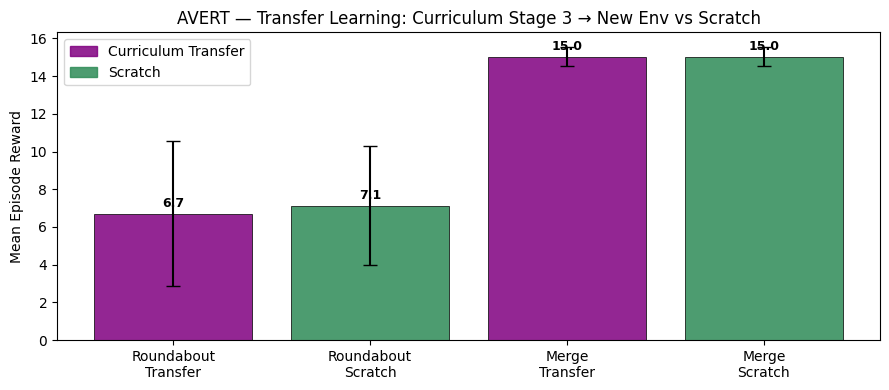

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:

# ── Transfer Bar Chart ────────────────────────────────────────────
xlabels = ["Roundabout\nTransfer", "Roundabout\nScratch",
           "Merge\nTransfer",      "Merge\nScratch"]
vals  = [ra_transfer['mean_reward'], ra_scratch['mean_reward'],
         mg_transfer['mean_reward'], mg_scratch['mean_reward']]
stds_t = [ra_transfer['std_reward'], ra_scratch['std_reward'],
          mg_transfer['std_reward'], mg_scratch['std_reward']]
bar_colors = ['purple', 'seagreen', 'purple', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(np.arange(4), vals, yerr=stds_t, color=bar_colors,
              capsize=5, alpha=0.85, edgecolor='k', linewidth=0.6)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(xlabels)
ax.set_ylabel("Mean Episode Reward")
ax.set_title("AVERT — Transfer Learning: Curriculum Stage 3 → New Env vs Scratch")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.2,
            f"{v:.1f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='purple',   alpha=0.85, label='Curriculum Transfer'),
    mpatches.Patch(color='seagreen', alpha=0.85, label='Scratch'),
])
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "transfer_bar.png"), dpi=150)
plt.show()

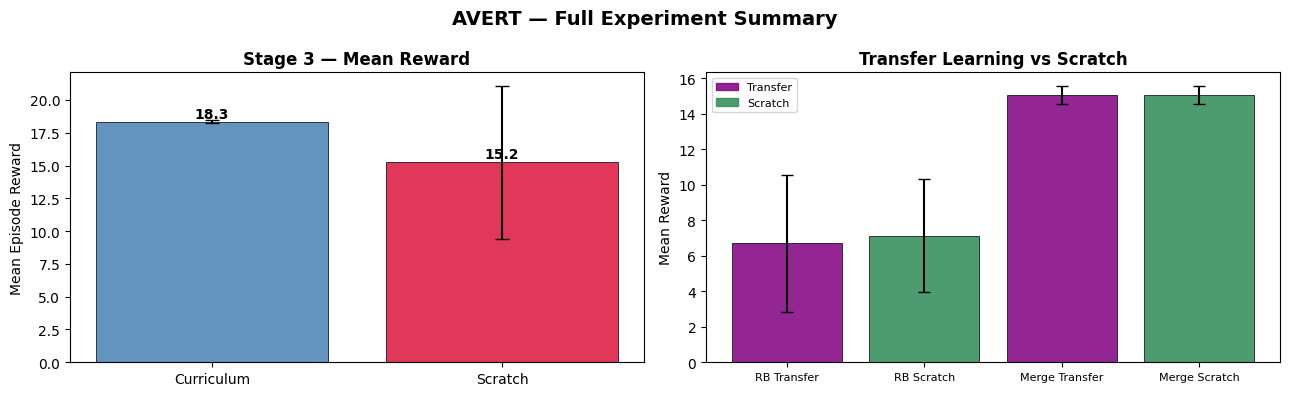

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:

# ── Summary Dashboard ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("AVERT — Full Experiment Summary", fontsize=14, fontweight='bold')

# Left: Stage 3 reward
ax = axes[0]
ax.bar(["Curriculum", "Scratch"],
       [s3_curr['mean_reward'], s3_scratch['mean_reward']],
       yerr=[s3_curr['std_reward'], s3_scratch['std_reward']],
       color=['steelblue', 'crimson'], alpha=0.85,
       capsize=5, edgecolor='k', linewidth=0.6)
ax.set_title("Stage 3 — Mean Reward", fontweight='bold')
ax.set_ylabel("Mean Episode Reward")
for i, v in enumerate([s3_curr['mean_reward'], s3_scratch['mean_reward']]):
    ax.text(i, v + 0.3, f"{v:.1f}", ha='center', fontweight='bold')

# Right: Transfer
ax = axes[1]
ax.bar(np.arange(4), vals, yerr=stds_t, color=bar_colors,
       alpha=0.85, capsize=4, edgecolor='k', linewidth=0.6)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(["RB Transfer", "RB Scratch", "Merge Transfer", "Merge Scratch"],
                   fontsize=8)
ax.set_title("Transfer Learning vs Scratch", fontweight='bold')
ax.set_ylabel("Mean Reward")
ax.legend(handles=[
    mpatches.Patch(color='purple',   alpha=0.85, label='Transfer'),
    mpatches.Patch(color='seagreen', alpha=0.85, label='Scratch'),
], fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "avert_summary_dashboard.png"), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Printed Results Table ─────────────────────────────────────────
print("=" * 60)
print(f"{'AVERT RESULTS TABLE':^60}")
print("=" * 60)
print(f"{'Condition':<25} {'Mean R':>8} {'Std':>7} {'Survival':>9}")
print("-" * 60)
for name, s in [
    ("Stage 3 (Curriculum)", s3_curr),
    ("Stage 3 (Scratch)",    s3_scratch),
    ("Roundabout Transfer",  ra_transfer),
    ("Roundabout Scratch",   ra_scratch),
    ("Merge Transfer",       mg_transfer),
    ("Merge Scratch",        mg_scratch),
]:
    surv_str = f"{s['survival_rate']*100:.0f}%"
    print(f"  {name:<23} {s['mean_reward']:>8.2f} {s['std_reward']:>7.2f} {surv_str:>9}")
print("=" * 60)
print(f"  Curriculum advantage on Stage 3 : {s3_curr['mean_reward'] - s3_scratch['mean_reward']:+.2f}")
print(f"  Roundabout: transfer vs scratch : {ra_transfer['mean_reward'] - ra_scratch['mean_reward']:+.2f}")
print(f"  Merge:      transfer vs scratch : {mg_transfer['mean_reward'] - mg_scratch['mean_reward']:+.2f}")

                    AVERT RESULTS TABLE                     
Condition                   Mean R     Std  Survival
------------------------------------------------------------
  Stage 3 (Curriculum)       18.35    0.14      100%
  Stage 3 (Scratch)          15.24    5.81       50%
  Roundabout Transfer         6.71    3.85       60%
  Roundabout Scratch          7.13    3.17       70%
  Merge Transfer             15.03    0.52      100%
  Merge Scratch              15.03    0.52      100%
  Curriculum advantage on Stage 3 : +3.11
  Roundabout: transfer vs scratch : -0.42
  Merge:      transfer vs scratch : +0.00


=== Curriculum Agent — Stage 3 ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Episode 1: reward=17.39  [survived]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Episode 2: reward=17.50  [survived]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


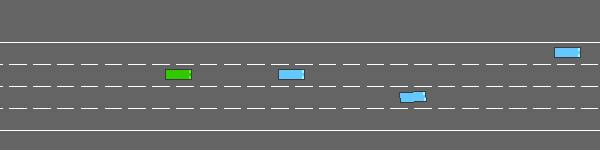

  Avg reward: 17.45 | Survival: 100%
=== Scratch Agent — Stage 3 ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Episode 1: reward=19.00  [survived]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Episode 2: reward=17.50  [survived]


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


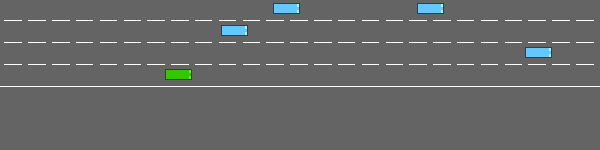

  Avg reward: 18.25 | Survival: 100%
=== Roundabout Transfer ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Episode 1: reward=8.82  [survived]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Episode 2: reward=8.82  [survived]


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


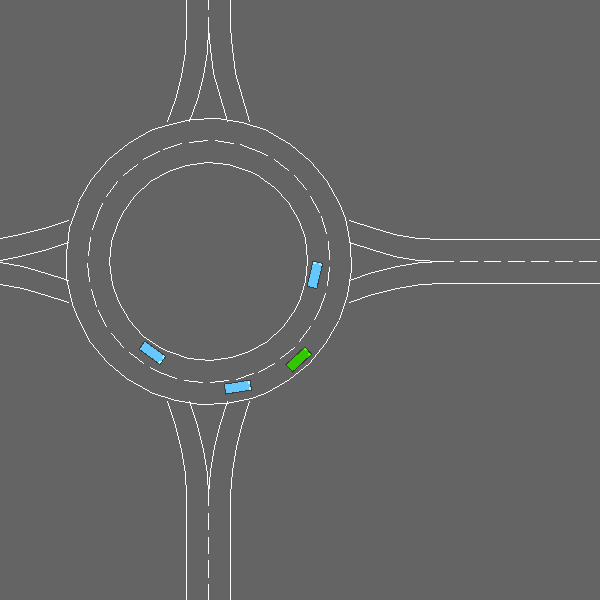

  Avg reward: 8.82 | Survival: 100%


In [13]:
print("=== Curriculum Agent — Stage 3 ===")
render_agent(model_curriculum, stage3_config, filename="curriculum_stage3.gif", n_episodes=2)

print("=== Scratch Agent — Stage 3 ===")
render_agent(model_scratch, stage3_config, filename="scratch_stage3.gif", n_episodes=2)

print("=== Roundabout Transfer ===")
render_agent(model_roundabout_transfer, roundabout_config,
             env_id="roundabout-v0", filename="roundabout_transfer.gif", n_episodes=2)

In [14]:
print(SAVE_DIR)

/content/drive/MyDrive/AVERT/
